## <span style="color:crimson; background-color:white">딥러닝 ① FOCUS ON IMAGE + SEQUENCE</span>

### <span style="color:crimson; background-color:white">1. 합성곱 신경망 (CNN, Convolutional NN)</span>

<span style="color:white; background-color:hotpink">픽셀과 채널</span>
 - 픽셀(pixel)
    - 입력 이미지의 가장 기본적인 데이터 단위
    - 이미지의 각 점에서 밝기/색상을 나타내는 값  
    ->이미지 데이터 = 픽셀이라고 하는 작은 이미지를 직사각형 형태로 모은 것  
    각 픽셀은 단색의 직사각형이며, 전체 이미지의 크기는 (세로픽셀수)*(가로픽셀수) 형식으로 표현  
    이미지 데이터를 저장할 때는 픽셀의 색을 표현하는 값을 2차원 배열로 표현 (NumPy ndarray)

<span style="color:white; background-color:hotpink">픽셀 값</span>
- 색공간: 픽셀의 색을 숫자로 표현하는 방식
- 대표적인 색공간: 그레이스케이, RGB, HSV(hue-saturation-value색, 채도, 명도)

1. 그레이 스케일(흑백 이미지)
- 채널 값 = 1
- 각 픽셀은 명도를 나타내는 숫자로 표현
    - 0: 검은색 / <span style="color:crimson">커질수록 하얀색</span>
    - 숫자는 0~255 사이의 8비트 부호 없는 정수로 저장
    - 이미지 데이터는 채널(1)*세로 픽셀 수 * 가로 픽셀 수 형태의 2차원 배열로 저장

2. RGB (컬러 이미지)
- 채널 값 = 3
- RGB 색공간에서 색은 red, green, blue 3가지 색의 명도를 뜻하는 숫자 3개가 합쳐진 벡터로 표현


### <span style="color:crimson; background-color:white">CNN 개념 설명</span>

원본 이미지: 컴퓨터는 이미지를 인식할 수 없으므로, 원본 이미지를 컴퓨터가 이해할 수 있도록 픽셀 단위로 구분
    - 각 픽셀에 대해 RGB 값이 적절히 조합되어 하나의 픽셀의 색상 정보를 나타냄

- 픽셀 정보들을 그냥 학습하면?
    - 컴튜터는 픽셀 값들이 모여서 하나의 완전한 이미지를 만드는 걸 모른다.
    - 픽셀 단위로 나누고 이걸 그냥 모델이 학습하도록 하면 **순서가 뒤섞인 채로 학습**하게 된다.
-> 원본 이미지에서 강아지의 "특징(눈, 귀 꼬리)"가 사라지게 된다.

<span style="color:hotpink; background-color:grey">**이미지 공간정보**</span>
- 사람들은 이미지 전체의 모든 부분을 하나하나 다 보지 않는다.
- 물체(강아지,고양이)가 존재하는 영역 위주로 살펴본다.
- 물체의 특징(눈,코,입 모양)을 위주로 살펴본다.
- 이미지 공간정보를 유지한 상태로 학습이 가능한 방식이 CNN

MLP와 CNN의 차이
- MLP = FC 레이어 + FC 레이어 + ... + FC 레이어 ( <span style="color:cyan; background-color:grey">**FC 레이어=fully connected layer-딥러닝에서 모든 입력과 모든 출력이 서로 연결된 층**</span>)  
- CNN = (Conv + Pool) + ... + (Conv + Pool) + Flatten(<span style="color:black; background-color:yellow">Flatten() 레이어는 입력 데이터의 형태를 변경하지 않고 1D 벡터로 변환 / Flatten은 numpy에서 제공하는 다차원 배열 공간을 1차원으로 평탄화해주는 함수</span>) + FC Layer + ... + FC Layer  

<span style="color:hotpink; background-color:grey">**MLP** : FC 레이어를 활용 -> 분류 진행</span>  
<span style="color:hotpink; background-color:grey">**CNN** : (Conv + Pool) 으로 특징을 유지 -> FC 레이어 적용 -> 분류 진행</span>

### <span style="color:white; background-color:hotpink">1-1. 왜 이미지 처리에 CNN을 사용할까? MLP안 쓰고?</span>

결론: 이미지는 픽셀의 <span style="color:hotpink; background-color:grey">**공간적 관계**</span>가 중요  
- MLP: 픽셀을 <span style="color:cyan; background-color:grey">**일렬로 펼쳐**</span> 처리
- CNN: 이미지의 <span style="color:cyan; background-color:grey">**2차원 구조**</span> 를 유지한 채 <span style="color:cyan; background-color:grey">**주변 픽셀 관계**</span> 와 시각적 특징을 학습

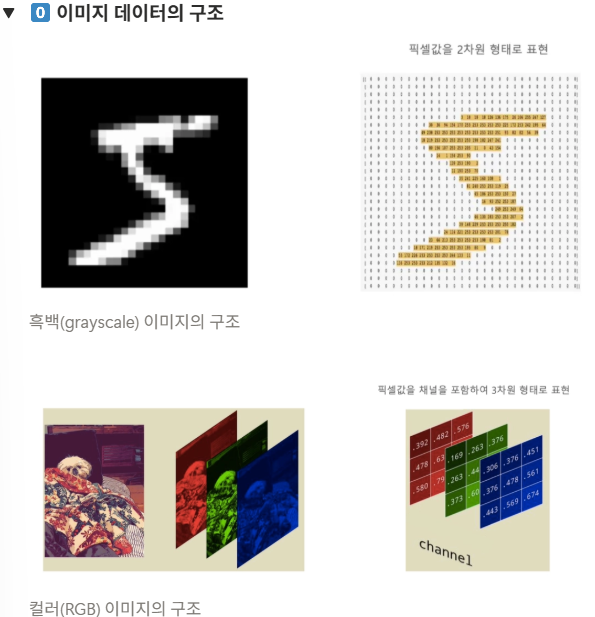

- 데이터 형식: 개별 값을 H x W 행렬로 나타낼 수 있음. 컬러의 경우 H x W x 3 구조.
- 대표적인 이미지 데이터셋: MNIST
    - 28*28 픽셀의 grayscale(흑백) 숫자 손글씨 이미지
    - CNN을 활용하여 이미지의 숫자를 인식한 분류 모델을 만들 수 있음

### MLP안쓰는이유1️⃣
MLP는 <span style="color:hotpink; background-color:grey">**위치, 크기, 회전 등의 변화에 취약**</span>

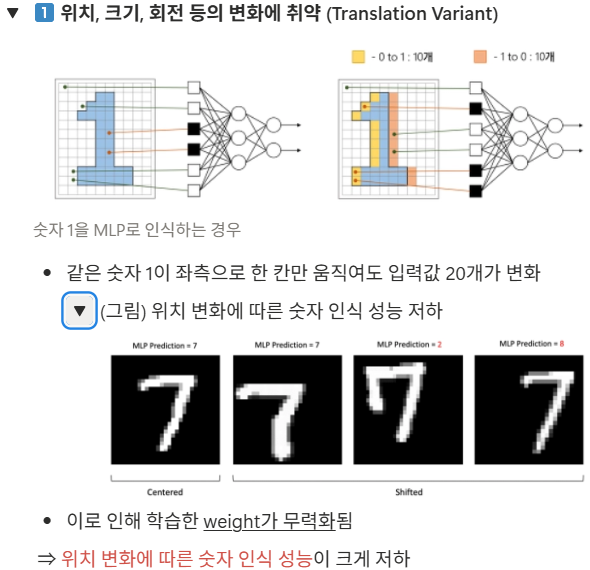

입력값이 많이 변화하면 가중치가 무력화된다!
겨우 정보의 경중?을 학습해서 가중치를 매겨놨는데 무력화되면 ㄹㅇ 아깝겟다
- 위치 변화에 따른 숫자 인식 성능이 크게 저하

CNN에서는?
Convolution으로 특징(feature) 추출: 모델이 ‘특징’을 학습한다.
Pooling으로 차원 축소: 위치/크기 변화에 덜 민감하게 만든다.
어떤 영역에 특정한 특징이 존재하는가를 보기 때문에 위치에 무관하다!

-  <span style="color:cyan; background-color:grey">**컨볼루션(Convolution, 합성곱)은**</span> 두 함수 \(f, g\) 중 하나를 반전(flip) 및 이동(shift)시켜가며 곱한 후, 그 결과를 적분(연속) 또는 합산(이산)하여 새로운 함수를 만드는 수학 연산
-  <span style="color:cyan; background-color:grey">**풀링(Pooling)은**</span> 2차원 데이터의 세로 및 가로 방향의 공간을 줄이는 연산

### MLP안쓰는이유2️⃣ 불안형 MLP ㅠㅠ
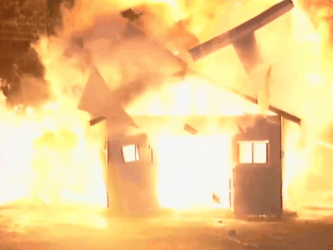  
파라미터 폭발 (Parameter Explosion)  
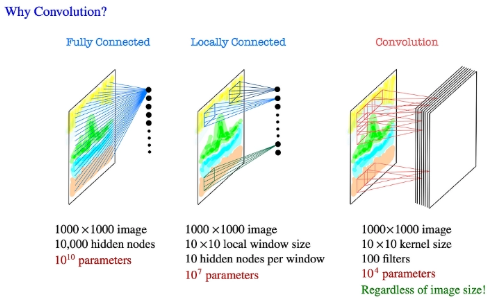  
1000*1000 이미지를 10,000개 노드로 완전 연결하는 경우 100억개의 파라미터가 필요함

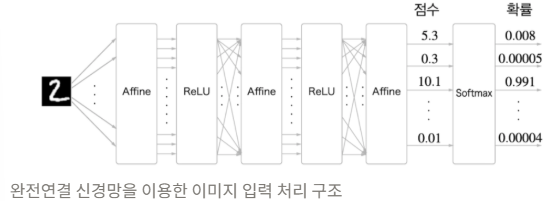  
MLP의 문제점: - (1) 완전연결(fully connected) 구조로 인한 파라미터 급증
- (2) 가중치 수가 이미지 픽셀의 개수만큼 생성
- (3) 과적합 가능성 상승, 이미지가 클수록 학습이 느림

    - 반면 CNN: <span style="color:white; background-color:hotpink">안정형 ♡</span>  
    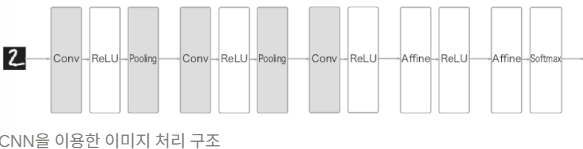
        - 부분연결 구조 & 합성함수(Conv) 연산으로 이미지의 특정 피쳐에만 집중
        - 효율적인 파라미터 사용: 위 예시에서 파라미터 수가 1000배 차이!
        와 선 개수 깔끔한 거 보면 진짜 안정형

### MLP안쓰는이유 3: 공간 정보 손실 (Loss of Spatial Info)  
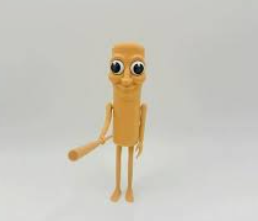  
퉁퉁퉁사후르도 아니고 정보를 바로 납작하게 만들어버리는 MLP  
MLP 너 진짜 폐급이다  
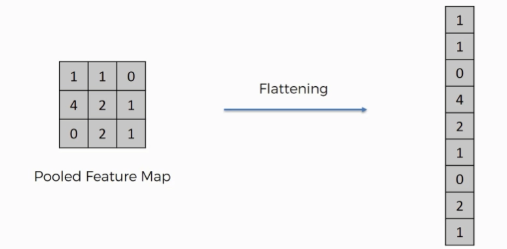  
MLP: 이미지를  <span style="color:black; background-color:yellow">1차원 벡터로 바로 변환</span>(flatten)  
<span style="color:cyan; background-color:grey">**근데 CNN에도 flatten 레이어는 사용되는데**</span>, 특징을 어느 정도 추출한 후 flatten하기 때문에 손실의 정도가 훨씬 낮다.

### <span style="color:white; background-color:hotpink">1-2. 합성곱(Convolution)과 풀링(Pooling)</span>

이미지의 특징을 추출하는 방법  
풀링은 이름 귀여운데 합성곱은 ㅈㅉ 안귀여움  

CNN 모델은 크게 두 부분으로 나뉨
1. 특징 추출(Feature Learning) - conv, pooling이 담당
2. 클래스 분류(Classification) - Fully Connected Layer가 담당
이미지의 클래스는 뭘까?

<span style="color:hotpink; background-color:grey">**1. Convolution Layer**</span>
전체 이미지를 일정 크기의 필터로 흝으면서 이미지의 특징을 학습

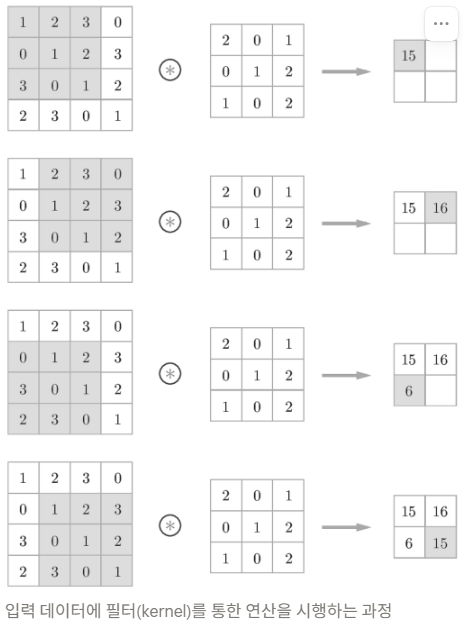  


1. 필터(Filter) 또는 커널(Kernel)이 이미지 위를 슬라이딩
a. CNN의 필터 값은 MLP의 가중치(weight)와 같은 역할을 함

2. 각 위치에서 요소별 곱셈 후 합계 계산

3. 결과를 Feature Map에 저장
a. feature map: input data에 filter를 적용하여 얻은 결과물
b. feature map의 차원은 filter의 수에 따라 결정됨.
(활성화된 정도를 나타낸다는 점에서 activation map이라고도 부름)  
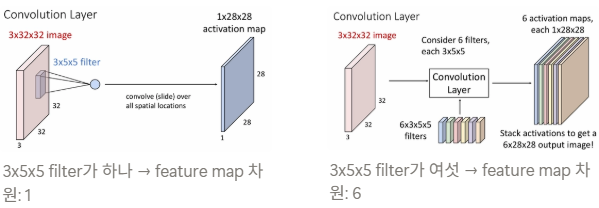

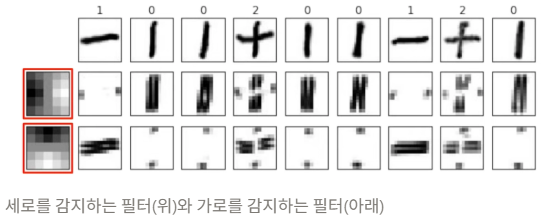  
- 5x5 필터가 이미지를 훑으면서 특징을 추출
- 각 필터는 특정한 패턴(예: 세로선, 가로선, 대각선)을 감지
- 여러 개의 필터를 사용해 다양한 특징을 추출

<span style="color:white; background-color:hotpink">2. Padding</span>  
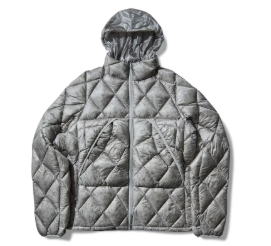  
filter를 거치며 정보를 잃어버리는 것을 막기 위해 이미지 바깥을 0으로 둘러싸는 기법  
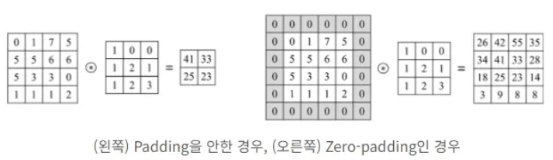  
- padding = 1로 설정했을 때의 연산 과정
- padding을 적용하지 않으 ㄴ경우 feature map으 크기는 2*2 ->padding 적용 시 4 *4
    ->이미지 크기를 유지하면서 가장자리 특징까지 반영할 수 있음
        - 예시: 액자  
        원래의 사진 크기를 유지하며, 액자를 사용하기 위해 사진 가장자리에 빈 공간을 추가하는 것

<span style="color:white; background-color:hotpink">3. Stride (보폭)</span>  
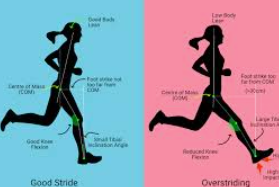  
- 이미지를 몇 칸씩 점프하면서 흝을 것인지 결정하는 값
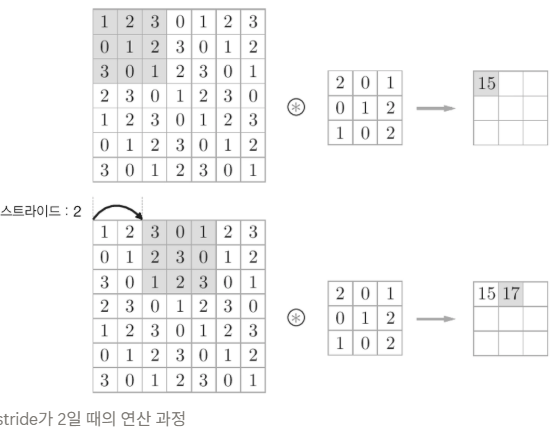  
    - stride = 1: 한 칸씩 이동( 세밀한 특징 추출)  
    - stride = 2: 두 칸씩 이동(빠른 처리, 크기 축소)  
    ->계산량 감소, 겹치는 영역을 줄여 효율적으로 요약
 <span style="color:cyan; background-color:grey">**stride가 커질수록 feature map의 크기가 작아진다**</span>     
     작아지는 이유: stride가 1보다 크면(예: stride=2) 필터가 한 번에 여러 칸을 건너뛰며 계산하기 때문에, 전체 데이터를 훑는 횟수가 줄어들어 최종 출력 feature map의 가로, 세로 크기가 줄어듭니다.공식: 입력 크기 \(H\), 필터 크기 \(F\), 패딩 \(P\), 스트라이드 \(S\)일 때, 출력 크기는 \(\frac{H + 2P - F}{S} + 1\)로 계산되며, 분모인 \(S\)(stride)가 커지면 결과값은 작아집니다.

<span style="color:white; background-color:hotpink">4. Pooling</span>  
피처맵에서 특징을 추출하기 위해 이미지를 격자 형태로 분할한 뒤, 해당 영역 안에서 가장 큰 값 또는 평균값을 취하는 것  
    - 어원: Pool은 보통 '물웅덩이'로 알고 있지만, 명사로는 공동 자금, (공동의) 정보/자원 등을 하나로 모아놓은 것을 의미  
    - 특정 영역(window)에 있는 픽셀 데이터들을 하나로 모아서(Pooling) 그 안에서 가장 큰 값(Max)이나 평균값(Average)을 대표값으로 뽑아내는 기술이기 때문에 'Pooling'이라는 이름이 붙었음

**Pooling의 종류**  
Max Pooling: **최댓값** 선택  
Average Pooling: **평균값** 선택  

💡 대부분의 경우 max pooling을 사용!  
- 이유: Max Pooling: 특징 추출 및 노이즈 감소에 우수 (가장 흔함).Average Pooling: 특징을 부드럽게(Smoothing) 할 때 사용하지만, 때로는 중요 정보를 희석시킬 수 있음.
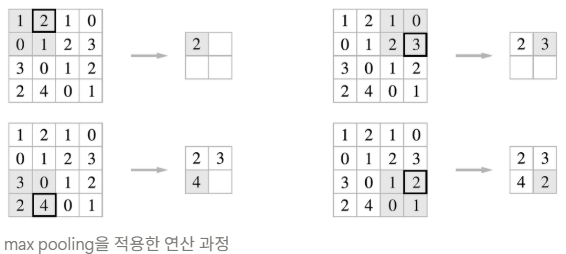  
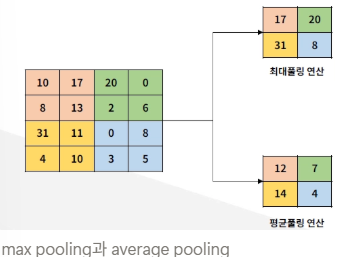  

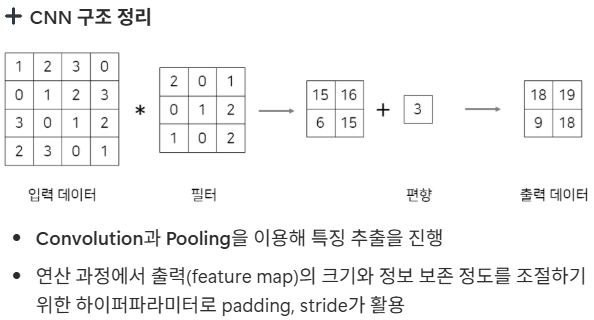

번외: 3채널(RGB) 컬러 이미지의 컨볼루션(합성곱) 연산 과정  
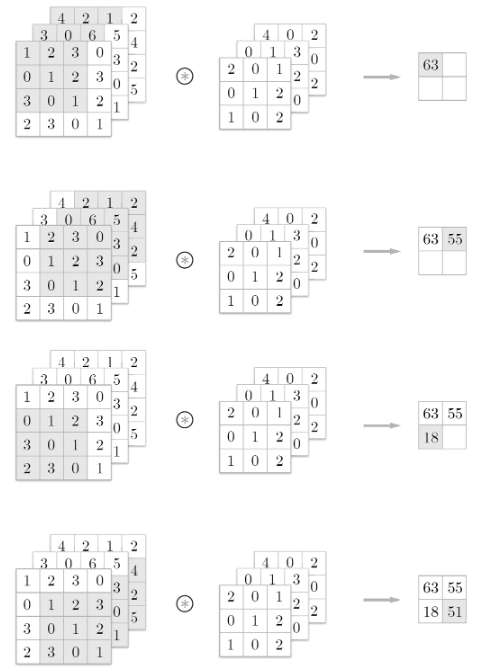  
이것뭐예요...?

<span style="color:white; background-color:hotpink">1-3. 대표적인 CNN 아키텍처 살펴보기</span>  
 AlexNet (2012)  
 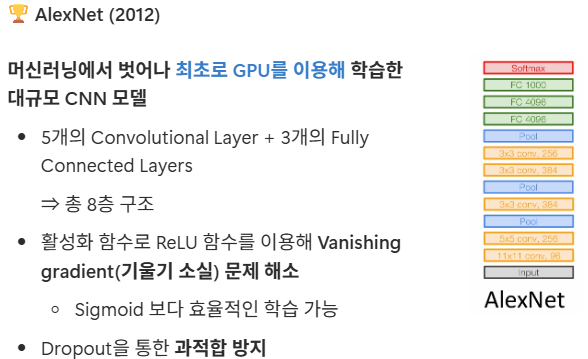  
오우..얘네 어케 외우지

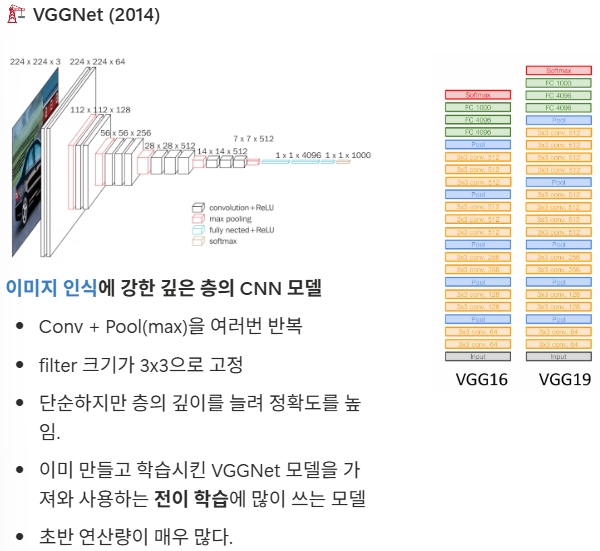

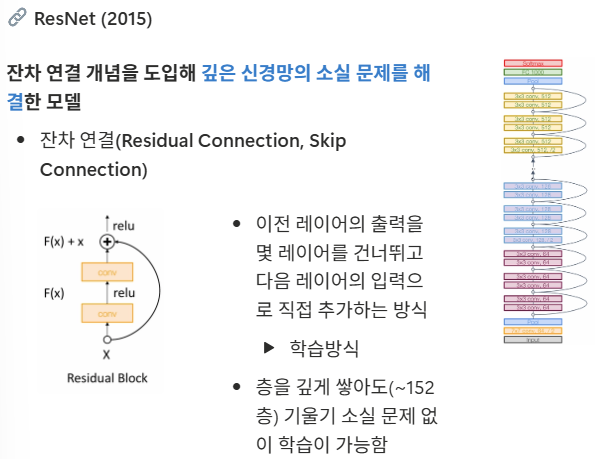

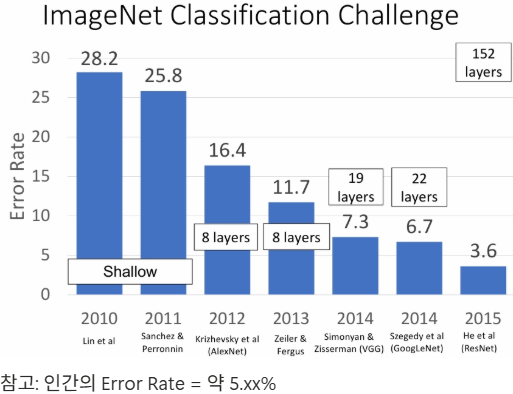

## <span style="color:crimson; background-color:white">2. 이미지 딥러닝 응용</span>

<span style="color:white; background-color:hotpink">2-1. 이미지 분류 (Image Classification)</span>

이미지를 수치 데이터(픽셀 값)로 인식 → 사전 정의된 클래스 중 하나로 분류

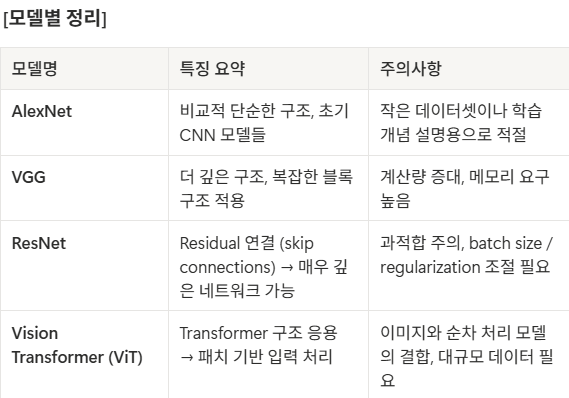  

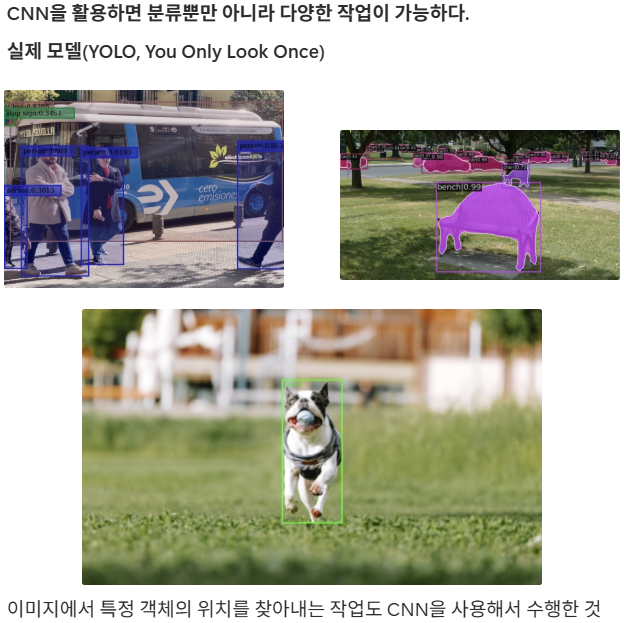

<span style="color:white; background-color:hotpink">2-2. 객체 탐지 (Object Detection)</span>

객체 검출(object detection)은 한 이미지에서 객체와 이 객체를 둘러싸는 가장 작은 직사각형으로 정의되는 bounding box를 찾는 작업  
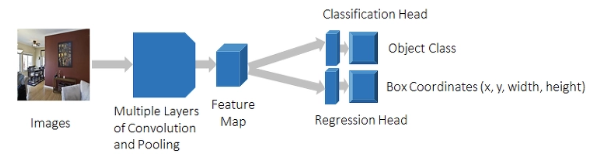  

[모델 적용 방식]
- CNN을 통해 Feature Map을 얻고, 그 위에 두 가지 head를 올림:
    - Classification Head: 객체의 클래스 예측
    - Regression Head: 객체의 위치 (x, y, width, height) 좌표 예측
- 대표 모델: YOLO, Faster R-CNN, SSD 등

<span style="color:white; background-color:hotpink">2-3. 이미지 캡셔닝 (Image Captioning)</span>

image captioning은 이미지 내에 있는 객체에 대한 판단뿐만 아니라 객체들 간의 관계를 파악하고 자연어의 형태로 알맞게 표현
- <span style="color:hotpink; background-color:grey">**관계 파악 (Contextual Understanding):**</span> "사람이 자전거를 타고 있다"와 같이, 주어(사람)와 목적어(자전거) 사이의 공간적, 행동적 관계를 해석
- <span style="color:hotpink; background-color:grey">**자연어 생성:**</span>: 파악한 정보를 바탕으로 '파도를 타는 서퍼', '공을 잡는 야구선수'와 같이 사람이 이해할 수 있는 자연스러운 문장을 만들어냄

[모델 적용방식: CNN과 RNN]
이미지 특징을 추출하기 위한 CNN과 문장으로 나타내기 위한 RNN

[이미지 캡셔닝 단계]
- CNN을 이용한 특징 추출
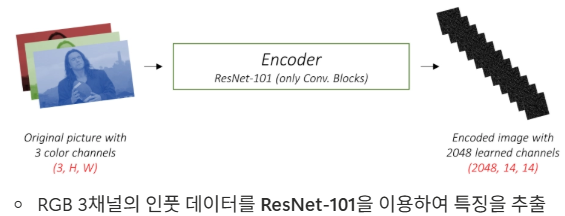

- Attention Network를 이용하여 단어 생성
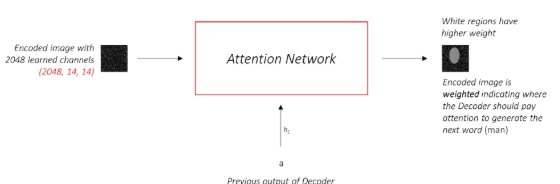  
    - Attention Network를 통과하여 중요한 부분에 가중치를 두어 단어를 추출
    - 가중치가 높은 부분을 이용해 사진을 한 문장으로 설명할 수 있게 함

<span style="color:hotpink; background-color:grey">**RNN을 이용하여 문장 완성**</span>  
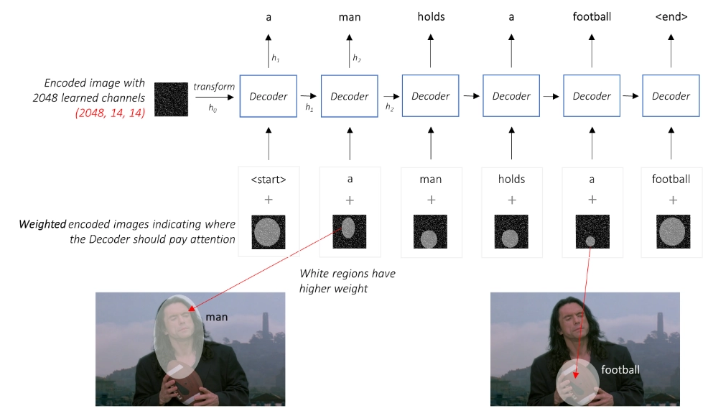  

흠.. 이 사진만 봐서는 원리가 완전 이해가지는 않는다...

## <span style="color:crimson; background-color:white">3. 과거를 기억하는 신경망: RNN (Recurrent Neural Network)</span>

<span style="color:white; background-color:hotpink">3-1. 순차(Sequence) 데이터란?</span>  
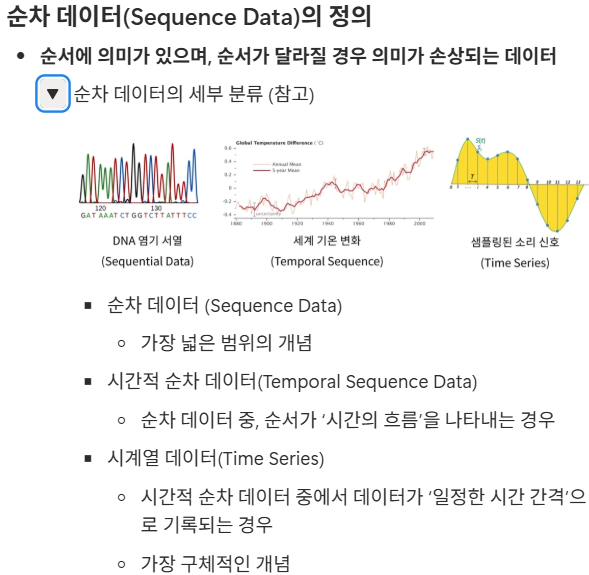  

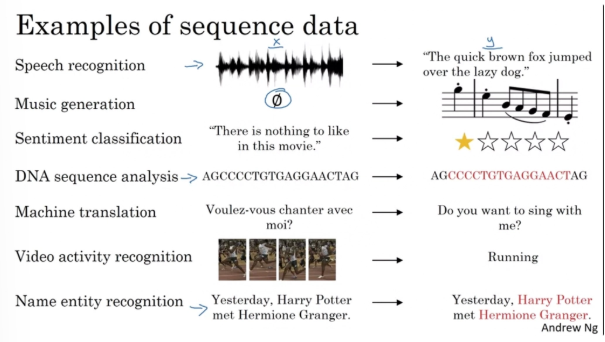  
순차 데이터의 예시  
1. 음성 및 오디오 데이터
    - 소리의 파형은 시간에 따라 연속적으로 변화하는 순차 데이터
2. 자연어
    - 문장, 단락, 문서 등 단어의 순서가 매우 중요한 대표적인 순차 데이터 <span style="color:hotpink; background-color:grey">**“I like you” ≠ “you like I”**</span>
3. 생물학적 서열 데이터
    - DNA, 단백질 서열처럼 특정 순서로 배열된 순차 데이터 <span style="color:hotpink; background-color:grey">**AGGGTC ≠ ACTGGC**</span>
4. 비디오 데이터
    - 여러 이미지 프레임이 순서대로 나열된 형태의 순차 데이터


**요소의 순서 의존성**: 데이터를 구성하는 요소들의 순서 자체가 핵심 정보  
 <span style="color:cyan; background-color:grey">**자기상관성**</span>: 이전 시점의 데이터가 다음 시점의 데이터에 영향을 미침

⇒ 순차 데이터의 이러한 특징을 고려하기 위해서는 기존의 머신러닝 기법으로는 한계가 있다.
⇒ 과거의 정보를 기억하고, 순서의 의미를 학습할 수 있는 **특별한 신경망**이 필요하다!

<span style="color:white; background-color:hotpink">3-2. RNN의 구조와 원리</span>


순환하는 구조를 가진, 순차 데이터 처리에 특화된 인공 신경망
“순환 신경망”

1. **시퀀스 데이터**를 입력받아 **순서 정보를 유지**하며 처리한다.
2. 순환하는 **은닉층**이 매 시점의 **은닉 상태**를 업데이트한다.
    - 은닉층 vs 은닉 상태
        - **은닉층 (Hidden Layer)**
            - 신경망을 구성하는 **물리적 요소**
            - 학습해야 할 **가중치**와 **활성화 함수** 포함
            - 정보를 어떻게 처리할지에 대한 **‘규칙’** 또는 **‘함수’** 그 자체
        - **은닉 상태 (Hidden State)**
            - 특정 시점($t$)에 은닉층을 통과한 **결과값**
            - 숫자로 이루어진 **벡터**
            - 해당 시점까지의 중요 정보를 요약한 **‘메모리’** 또는 **‘문맥’**
        
        |  | **은닉층 (Hidden Layer)** | **은닉 상태 (Hidden State)** |
        | --- | --- | --- |
        | 비유 | **컨베이어 벨트 🏭** | **컨베이어 벨트 위 물건** 📦 |
        | 정의 | 가중치와 활성화 함수를 가진 신경망의 **구성 요소** | 특정 시점의 정보를 요약한 **결과값 (벡터)** |
        | 역할 | 정보 처리 **'규칙' 또는 '함수'** | 과거 정보를 담고 있는 **'메모리', '문맥'** |
        | 시간에 따른 변화 | **변하지 않음** (가중치 공유) | 매 시점마다 **계속 변함** ($ht−1→ht$) |

아 여기 용어 입에 레전드 안붙음!!!!!!! ㅜㅜㅜㅜ

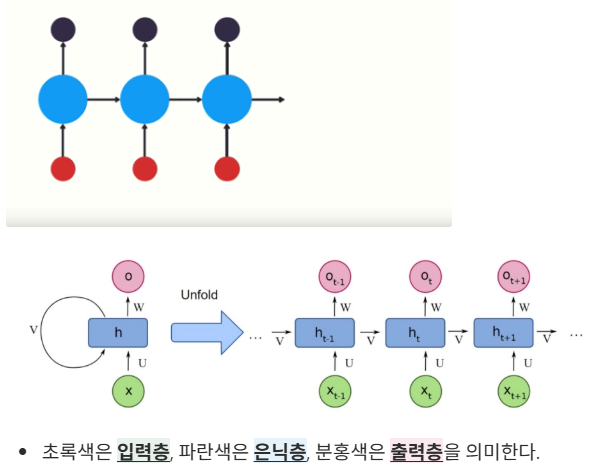

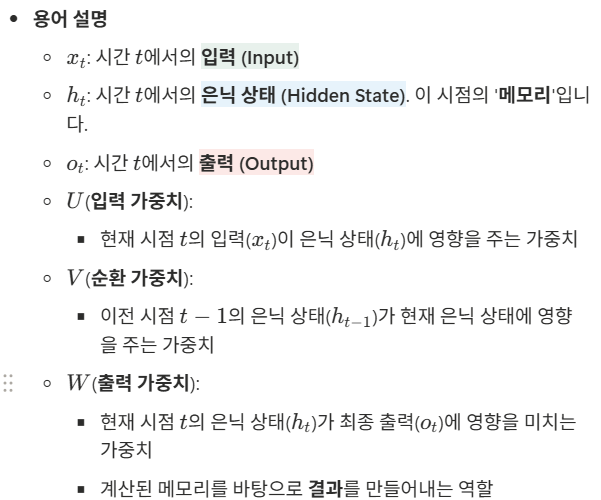


 ### <span style="color:cyan; background-color:grey">**기존 신경망과의 차이점**</span>  
- 순환 가중치의 유무
기존에 배웠던 신경망의 이미지를 생각해보면, 위 이미지에서의 V, 즉 순환 가중치가 존재하지 X.

- 하지만 RNN에서는 순환 가중치를 통해 이전 시점의 정보를 전달함.
위에서 적은 RNN을 뉴런 단위로 시각화하면 다음과 같음  
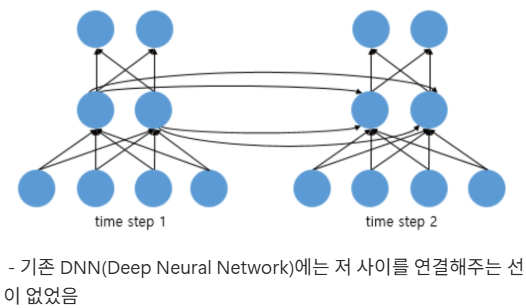  

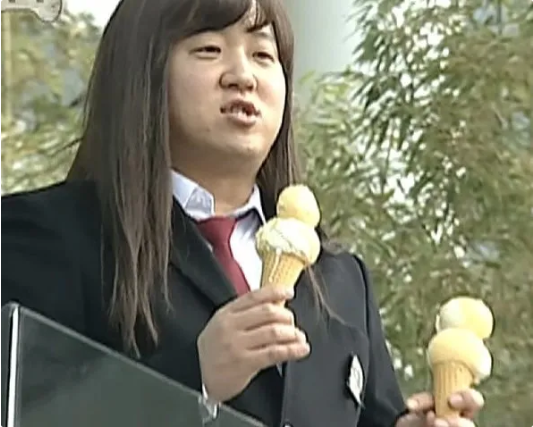  
정형돈 파티네요... 형도니를 누가 이렇게 조아할까  
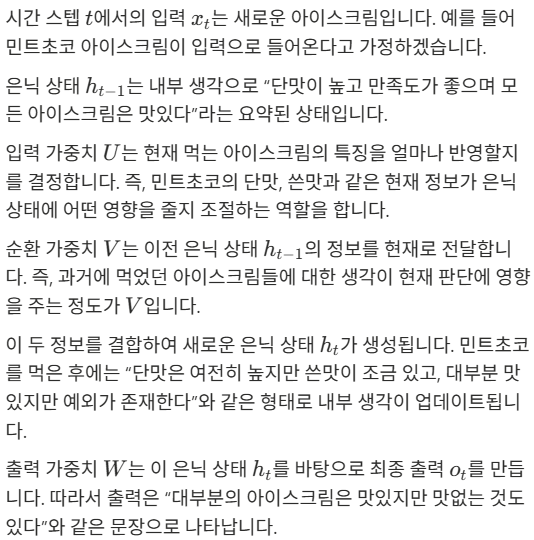  
먹는 걸로 설명하니까 이해가 싹된다  

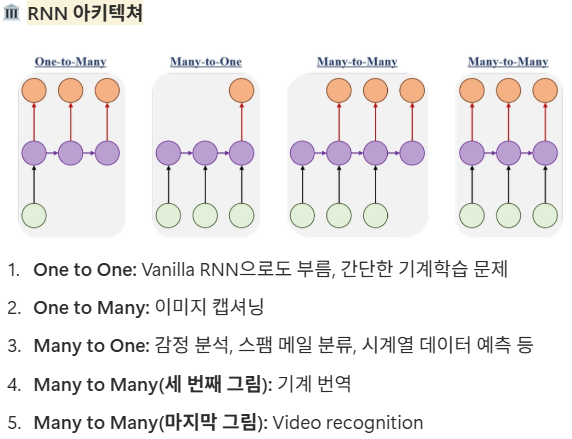

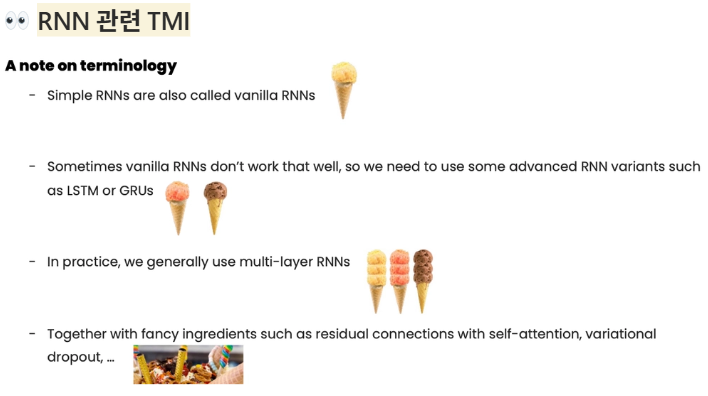  
파르페를 먹고 싶으면 rnn을 정~~~~~말 잘해야되는구나 나도 파르페 낋일래 ㅜㅜ  

<span style="color:black; background-color:yellow">RNN의 핵심 원리: 가중치 공유</span>

- 동일한 가중치를 시퀀스의 다양한 시점에서 반복적으로 적용
- RNN이 시퀀스 데이터의 길이와 시점 위치에 상관없이 효과적으로 작동하게 하는 핵심 원리

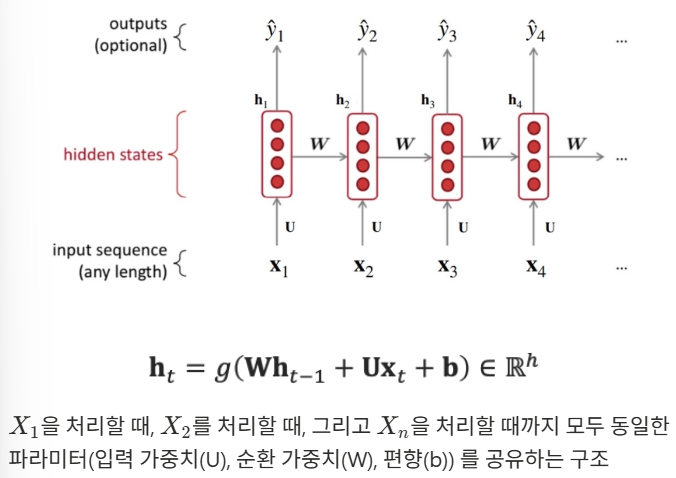

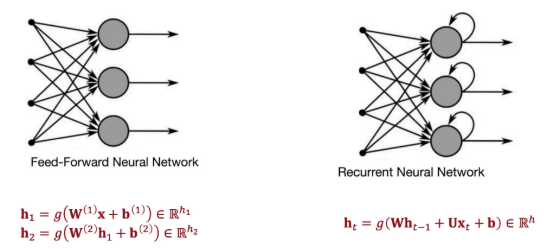
- 우리가 문장을 읽을 때, 첫 단어를 해석하는 ‘뇌’와 다섯 번째 단어를 해석하는 ‘뇌’가 다르지 않은 것과 같음
- 동일한 ‘문법 지식’을 활용해 각 단어를 순서대로 이해함
- RNN의 공유되는 가중치가 바로 이 ‘문법 지식’과 같은 역할 수행


 그렇다면 가중치 공유의 이점은?
학습 파라미터의 수 감소
- 가중치 공유를 통해 RNN은 입력 시퀀스의 길이가 아무리 길어져도 학습해야 할 파라미터의 수가 일정하게 유지
- 모델이 더 빠르고 가볍게 만들어짐
일반화 능력의 향상
- 훈련 데이터에 없던 새로운 길이의 시퀀스나 다양한 패턴에도 유연하게 대응 가능

<span style="color:white; background-color:hotpink">3-3. RNN의 한계 및 장기 의존성 문제 (The Long-Term Dependency Problem)</span>

<span style="color:cyan; background-color:grey">**역전파(Backpropagation)**</span>는 인공신경망에서 출력층의 오차를 입력층 방향으로 전파하며 가중치를 업데이트하는 핵심 지도 학습 알고리즘

RNN의 한계점
RNN 구조의 특성 상 전체 시퀀스를 모두 읽은 후 역전파가 이루어짐
 역전파를 구하는 과정에서 chain rule에 의해 다음 미분값이 반복적으로 곱해짐 (등비수열 형태)

- 기울기 소실
    - 시퀀스 뒤쪽의 오차가 앞쪽까지 제대로 전달되지 않아 먼 과거의 정보를 학습하지 못하는 현상 (기울기 1보다 작을 때)
- 기울기 폭주
    - 시퀀스 뒤쪽의 오차가 역전파 과정에서 비정상적으로 커지는 문제 (기울기 1보다 클 때)
- 느린 훈련 시간
    - 계산 과정이 순차적으로 이루어져야만 하는 구조적 한계


장기 의존성 문제 (Long-Term Dependency Problem)
위 세가지 RNN의 구조적 한계는 ‘장기 의존성 문제’라는 하나의 치명적인 약점으로 이어짐

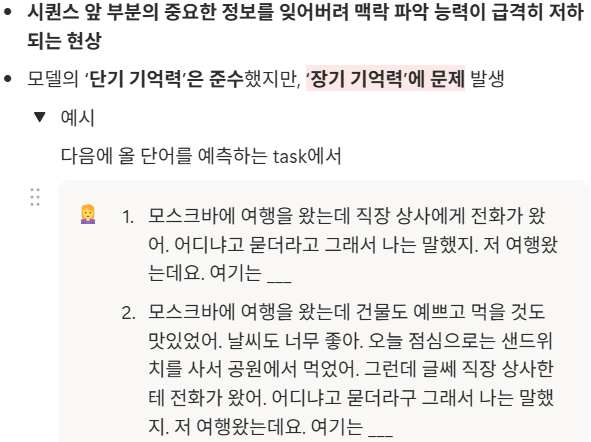  
이거 그거네 제타 문제



## <span style="color:crimson; background-color:white">4. 똑똑하게 기억하고 잊는 법: LSTM & GRU</span>

셀 상태 
𝐶
𝑡
C 
t
​
 ﻿ - 장기 기억): 이 기억은 절대 변하지 않는 핵심 기억
엘리트 (은닉 상태 
ℎ
𝑡
h 
t
​
 ﻿ - 단기 기억/출력):  현재 상황에서 바로 사용하는 기억. 셀 상태에서 필요한 정보만 꺼내서, 지금 시점에서의 판단이나 출력으로 사용함

 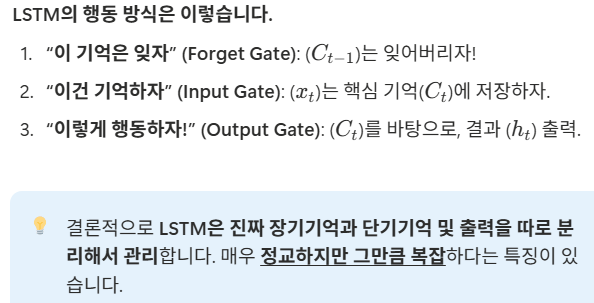

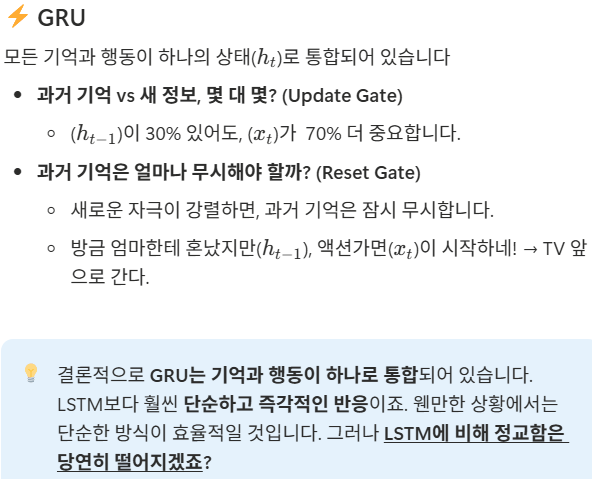


<span style="color:white; background-color:hotpink">4-1. 게이트(Gate)로 정보의 흐름을 제어하다: LSTM</span>

앞의 정보가 뒤로 충분히 전달되지 못하는 RNN의 기울기 소실 문제를 해결하기 위한 모델 구조

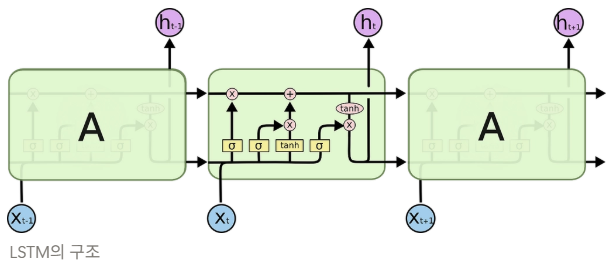

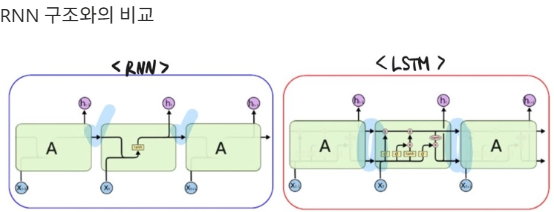

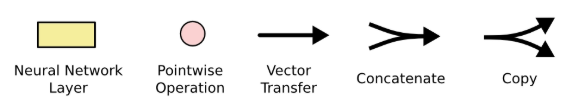  
Pointwise operation(점별 연산)은 수학 및 딥러닝에서 두 개 이상의 행렬(벡터, 텐서)을 연산할 때, 같은 위치에 있는 원소끼리 1대1로 연산하는 방식을 뜻

LSTM의 장점 & 단점
- 장점: Vanishing gradient problem 효과적으로 완화 (≠해결)
- 단점: (많이) 복잡한 구조, RNN보다 학습 파라미터가 많아짐

<span style="color:white; background-color:hotpink">4-2. 더 단순하고 효율적인 구조: GRU (Gated Recurrent Unit)</span>

GRU (Gated Recurrent Units)
LSTM에서 조금 더 발전한 것으로 별도의 메모리 셀 없이 게이트 수를 줄여 구조를 간소화!

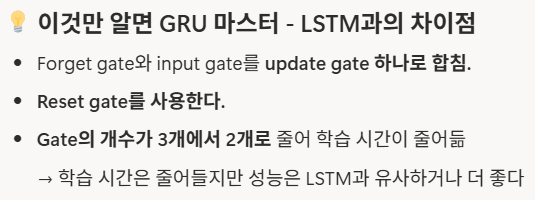

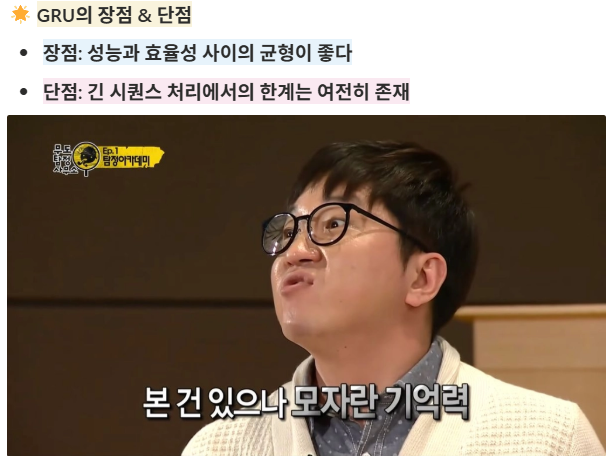

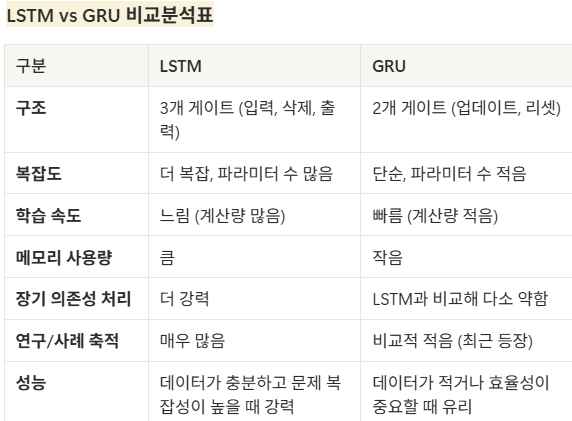





### <span style="color:crimson; background-color:white">5. 문장을 입력받아 문장을 출력하다: Seq2Seq</span>


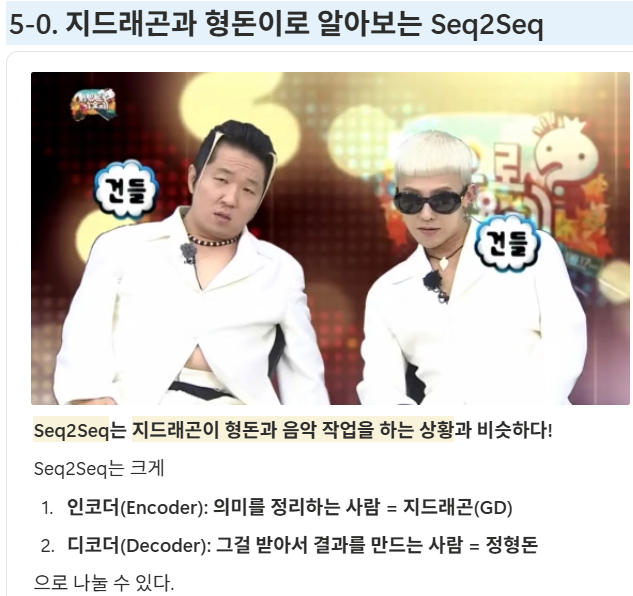  
ㅁㅊ 웃겨요 ㅜㅜㅜ

의미를 만드는 애, 인코더! = 지드래곤
- GD는 머릿속에 있는 음악 아이디어(Sequence)를 정형돈에게 전달한다.
- 이때 머릿속 생각은 길고 애매할 수 있다.
- 입력(Input Sequence):
“약간… 힙하면서도… 웃긴 느낌도 있고… 사람들이 따라하기 쉬운 그런 거…”  
인코더는 이 여러 개의 정보를 하나로 압축한다.  
핵심 의도 = 컨텍스트 벡터(context vector)  

듣고 결과 만드는 애, 디코더! = 정형돈
- 정형돈은 GD가 전달한 컨텍스트 벡터(context vector)를 받아서 결과를 만든다.
- 중요한 건, GD가 한 말을 그대로 따라하는 게 아니라 새로운 결과(Sequence)를 만들어낸다는 점이다.
- 출력(Output Sequence): 노래노래

- 한 시퀀스를 다른 시퀀스로 변환하는 작업을 수행하는 딥러닝 모델로, 대표적으로 기계번역에서 사용
    - 특징 1: 아이템(단어)의 입력 개수와 출력 개수가 같지 않아도 됨
    - 특징 2: 인코더와 디코더라는 모듈을 가지고 있어, Encoder-Decoder 모델이라고도 불림

    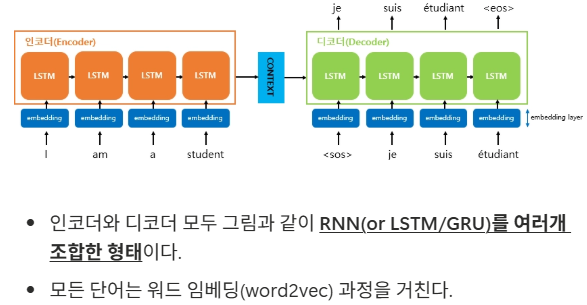


<span style="color:white; background-color:hotpink">5-2. Seq2Seq의 한계: 병목 현상 (Bottleneck)</span>

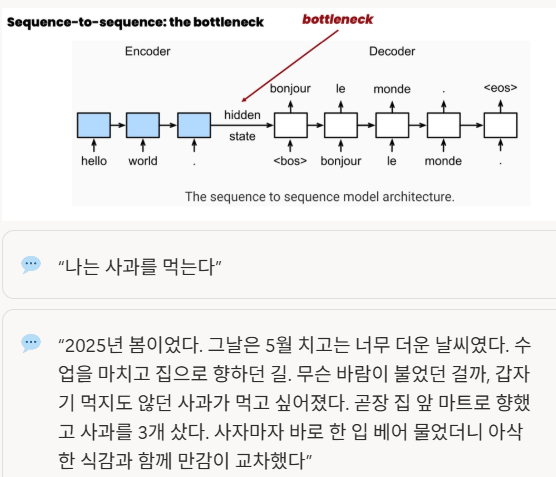

고정된 Context Vector에 소스 문장의 정보 압축 → 병목 현상 발생!!
고정된 길이에 입력 시퀸스의 모든 정보를 담지 못하고 손실될 수 있다.



### <span style="color:crimson; background-color:white">큰제목</span>


<span style="color:white; background-color:hotpink">작은제목</span>

<span style="color:hotpink; background-color:grey">**핵심 설명 하이라이트**</span>

 <span style="color:cyan; background-color:grey">**입에 잘 안 붙거나 잘 모르겠는 애들 하이라이트**</span>

 <span style="color:black; background-color:yellow">새로 나왔는데 그래도 이해 되는 애들 하이라이트</span>